# 한글 폰트 설치

In [1]:
# ── 나눔고딕 폰트 설치 (최초 1회, 이후 주석 처리 가능) ──────────────
!sudo apt-get install -y -qq fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share

In [2]:
import matplotlib.pyplot as plt
import platform
import seaborn as sns
import matplotlib.font_manager as fm     # 시스템에 설치된 폰트를 탐색하고 그래프 폰트로 등록해주는 매니저

# 한국어 폰트 설정 ───────────────────────────────────────────────────
font_dirs = ['/usr/share/fonts/truetype/nanum']         # 나눔 폰트가 설치되어 있는 시스템 폴더 경로 지정
font_files = fm.findSystemFonts(fontpaths=font_dirs)    # 지정한 경로에서 폰트 파일(.ttf) 목록을 모두 찾아 리스트로 반환
for ff in font_files:
    fm.fontManager.addfont(ff)                          # 찾은 개별 폰트 파일들을 Matplotlib 폰트 매니저에 사용할 수 있도록 등록

# ── 5. 시각화 전역 설정 (Wilke 스타일 + 폰트 통합) ──────────────────────────────
# Seaborn 테마 설정 (여기에 폰트를 지정해야 sns 그래프에서도 한글이 깨지지 않음)
sns.set_theme(
    style='whitegrid',                  # 배경을 하얗고 옅은 격자가 있는 스타일로 설정
    rc={
        'font.family': 'NanumBarunGothic', # 그래프의 기본 글꼴을 등록해둔 '나눔바른고딕'으로 설정 (한글 깨짐 방지)
        'axes.unicode_minus': False        # 한글 폰트 적용 시 축의 마이너스(-) 기호가 네모로 깨지는 현상 방지
    }
)

# Matplotlib 세부 스타일 설정 (흰 배경, 최소 격자, 고해상도)
plt.rcParams.update({
    'figure.dpi': 130,                  # 그래프의 해상도를 130 DPI로 설정하여 선명하게 출력
    'figure.facecolor': 'white',        # 그래프 바깥쪽 영역(Figure)의 배경색을 흰색으로 설정
    'axes.facecolor': '#FAFAFA',        # 그래프 안쪽 영역(Axes)의 배경색을 아주 옅은 회색으로 설정
    'axes.spines.top': False,           # 그래프의 위쪽 테두리 선을 숨김 (깔끔한 시각화를 위해)
    'axes.spines.right': False,         # 그래프의 오른쪽 테두리 선을 숨김
    'axes.grid': True,                  # 그래프 내부에 격자선을 표시하도록 설정
    'grid.alpha': 0.3,                  # 격자선의 투명도를 0.3으로 설정 (연하게 표시)
    'grid.linestyle': '--',             # 격자선의 모양을 점선(dash)으로 설정
    'axes.titlesize': 13,               # 그래프 제목(Title)의 글씨 크기를 13으로 설정
    'axes.labelsize': 11,               # x축, y축 이름(Label)의 글씨 크기를 11로 설정
    'xtick.labelsize': 9,               # x축 눈금 숫자들의 글씨 크기를 9로 설정
    'ytick.labelsize': 9,               # y축 눈금 숫자들의 글씨 크기를 9로 설정
    'legend.fontsize': 9,               # 범례(Legend)의 글씨 크기를 9로 설정
})

print('라이브러리 로드 및 시각화 환경 설정 완료')

라이브러리 로드 및 시각화 환경 설정 완료


# 라이브러리 가져오기

In [5]:
# 회귀 평가 지표 불러오기 (MSE, MAE)
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 시계열 분석 관련 함수 및 모듈
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf                        # ACF/PACF 시각화
from statsmodels.tsa.seasonal import seasonal_decompose, STL                         # 시계열 분해
from statsmodels.stats.diagnostic import acorr_ljungbox                              # Ljung-Box 테스트
from statsmodels.tsa.statespace.sarimax import SARIMAX                               # SARIMA 모델
from statsmodels.tsa.arima_process import ArmaProcess                                # ARMA 시뮬레이션
from statsmodels.graphics.gofplots import qqplot                                     # Q-Q 플롯
from statsmodels.tsa.stattools import adfuller                                       # ADF 단위근 검정
from tqdm import tqdm                                                                # 반복문 진행상황 표시
from itertools import product                                                        # 튜플 조합 생성
from typing import Union                                                             # 타입 힌팅

# 시각화 및 데이터분석에 필요한 패키지
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np

# 경고 무시 설정
import warnings
warnings.filterwarnings('ignore')

# Jupyter notebook에서 그래프를 inline으로 표시
%matplotlib inline

# 데이터 가져오기
- 출처 : https://rdrr.io/cran/fpp/man/a10.html
- 데이터 정의: 호주 건강보험 위원회(Australian Health Insurance Commission)에서 기록한 항당뇨병 약제(Anti-diabetic drug)에 대한 월별 정부 보조금 지출액 데이터입니다.
- 관측 기간: 1991년 7월부터 2008년 6월까지 (약 17년, 총 204개의 월별 관측치).
- 단위: 백만 달러 (Millions of dollars)


In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [7]:
# 데이터 파일이 저장된 경로를 설정합니다.
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/ts_data/'

# 'AusAntidiabeticDrug.csv' 파일을 읽어와 데이터프레임(df)로 저장합니다.
df = pd.read_csv(DATA_PATH + 'AusAntidiabeticDrug.csv')

# 데이터의 처음 10행을 확인합니다.
df.head(10)

,ds,y
0,1991-07-01,3.526591
1,1991-08-01,3.180891
2,1991-09-01,3.252221
3,1991-10-01,3.611003
4,1991-11-01,3.565869
5,1991-12-01,4.306371
6,1992-01-01,5.088335
7,1992-02-01,2.814520
8,1992-03-01,2.985811
9,1992-04-01,3.204780


In [8]:
df.tail(10)

,ds,y
194,2007-09-01,22.930357
195,2007-10-01,23.263340
196,2007-11-01,25.250030
197,2007-12-01,25.806090
198,2008-01-01,29.665356
199,2008-02-01,21.654285
200,2008-03-01,18.264945
201,2008-04-01,23.107677
202,2008-05-01,22.912510
203,2008-06-01,19.431740


In [9]:
df.shape

(204, 2)

# 데이터 시각화

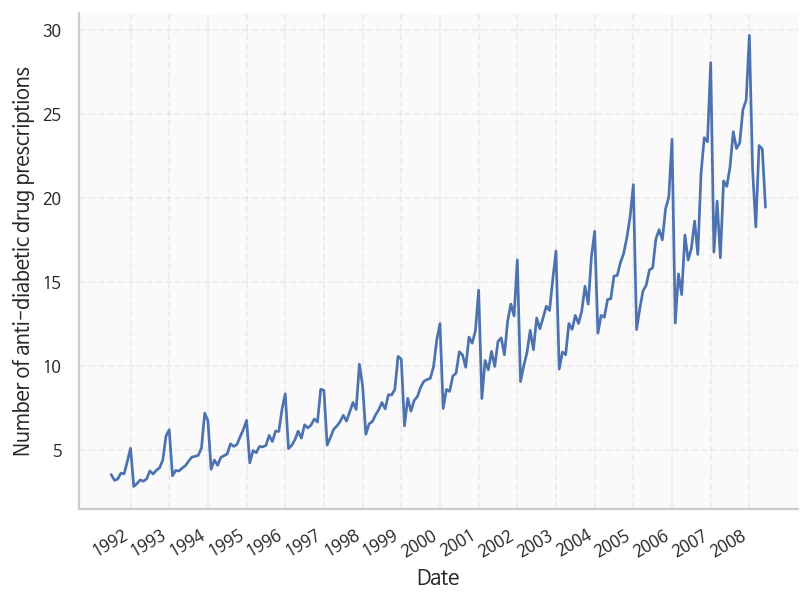

In [10]:
# 데이터 시각화를 위한 figure와 axes 생성
fig, ax = plt.subplots()

# 항당뇨제 약 처방건수(y 값) 시계열 그래프 그리기
ax.plot(df.y)

# x축, y축 레이블 설정
ax.set_xlabel('Date')
ax.set_ylabel('Number of anti-diabetic drug prescriptions')

# x축 눈금 및 라벨을 연도별로 지정
plt.xticks(np.arange(6, 203, 12), np.arange(1992, 2009, 1))

# x축 날짜 라벨 자동 회전
fig.autofmt_xdate()
# 레이아웃 자동 조정
plt.tight_layout()

# 그래프 출력
plt.show()

# 시계열 구성 요소 확인

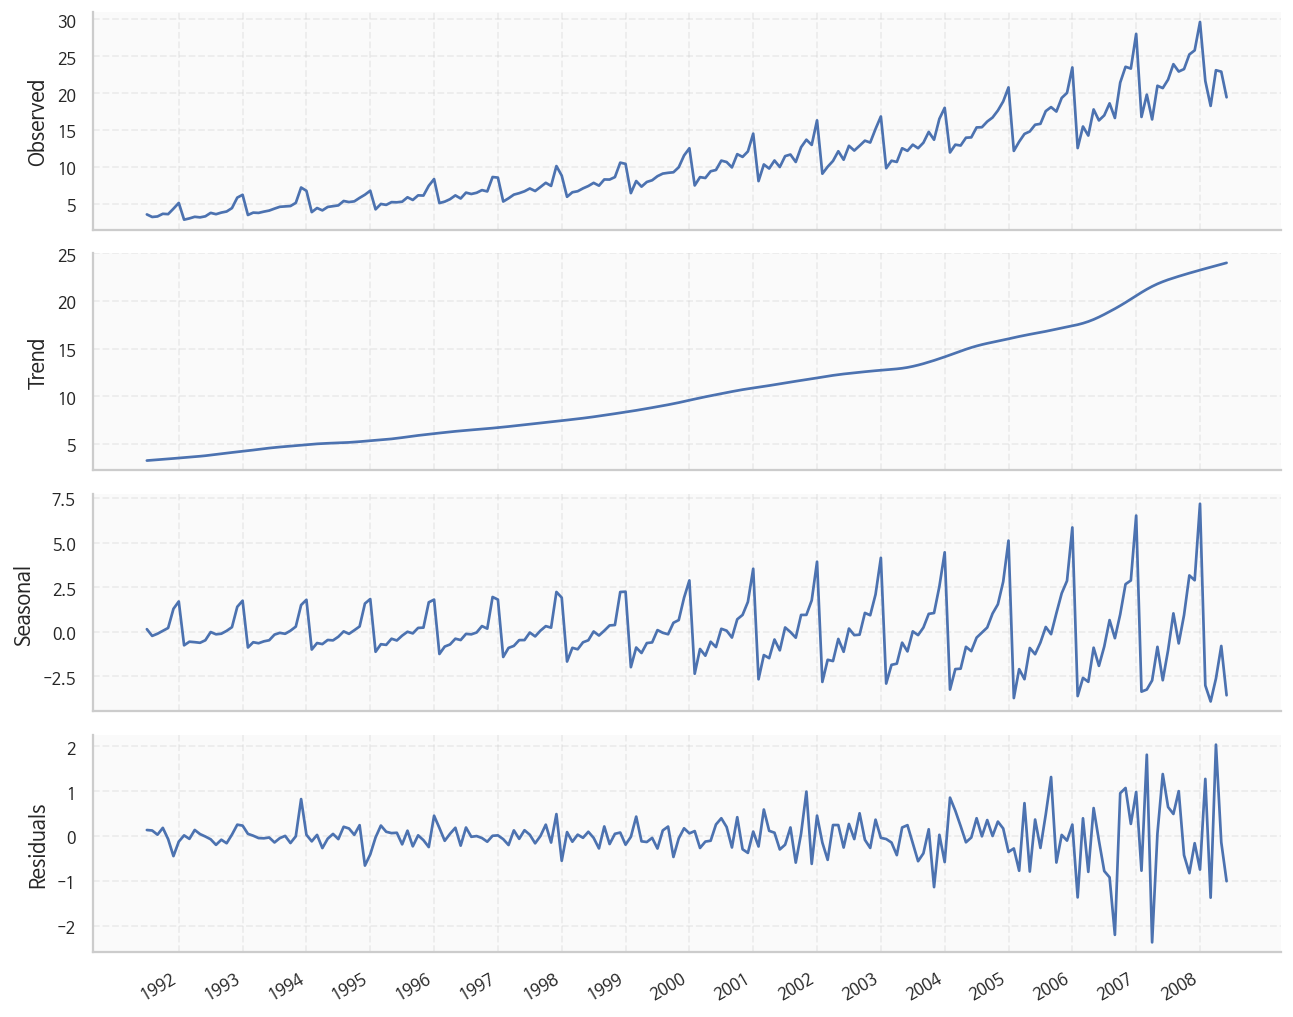

In [11]:
# STL을 이용한 시계열 분해를 위해 라이브러리 임포트
from statsmodels.tsa.seasonal import seasonal_decompose, STL

# STL로 시계열 분해 (주기: 12개월)
decomposition = STL(df.y, period=12).fit()

# 분해 결과 시각화를 위한 4개의 서브플롯 생성
fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10,8))

# 관측값(Observed) 시계열 그래프
ax1.plot(decomposition.observed)
ax1.set_ylabel('Observed')

# 추세(Trend) 시계열 그래프
ax2.plot(decomposition.trend)
ax2.set_ylabel('Trend')

# 계절성(Seasonal) 시계열 그래프
ax3.plot(decomposition.seasonal)
ax3.set_ylabel('Seasonal')

# 잔차(Residuals) 시계열 그래프
ax4.plot(decomposition.resid)
ax4.set_ylabel('Residuals')

# x축 레이블을 연도별로 지정
plt.xticks(np.arange(6, 203, 12), np.arange(1992, 2009, 1))

# x축 날짜 라벨 자동 회전
fig.autofmt_xdate()
# 레이아웃 자동 조정
plt.tight_layout()

# 그래프 출력
plt.show()

# 시계열 모델 만들기

## 정상성 확인
- 귀무가설 : 시계열은 정상성이 아니다
- 대립가설 : 시계열은 정상성이다

In [12]:
ad_fuller_result = adfuller(df.y)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: 3.145185689306745
p-value: 1.0


In [13]:
y_diff = np.diff(df.y, n=1)
ad_fuller_result = adfuller(y_diff)
print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -2.4951721474497903
p-value: 0.1166534168646754


In [14]:
# 월별 데이터이므로 12개의 시간 단계 만큼 떨어전 값 빼기
y_diff_seasonal_diff = np.diff(y_diff, n=12)
ad_fuller_result = adfuller(y_diff_seasonal_diff)
print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -19.84844009618371
p-value: 0.0


- 결론 : 1차 차분 및 1차 계절적 차분

## 훈련데이터 및 테스트 데이터셋 분리

In [15]:
train = df.y[:168]
test = df.y[168:]

print(len(test))

36


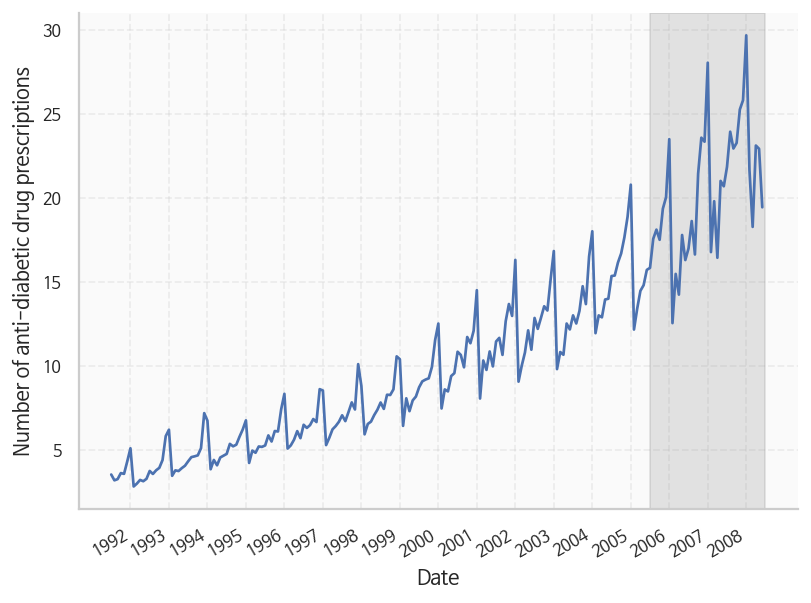

In [16]:
fig, ax = plt.subplots()

ax.plot(df.y)
ax.set_xlabel('Date')
ax.set_ylabel('Number of anti-diabetic drug prescriptions')
ax.axvspan(168, 204, color='#808080', alpha=0.2)

plt.xticks(np.arange(6, 203, 12), np.arange(1992, 2009, 1))

fig.autofmt_xdate()
plt.tight_layout()

# plt.savefig('figures/CH11_F_peixeiro.png', dpi=300)

## 최적의 SARIMA 모델 발견
- SARIMA(p,1,q)(P,1,Q)<sub>12<sub>
- AIC를 최소화할 수 있는 p, q, P, Q의 값을 찾는 함수

In [17]:
from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX

def optimize_SARIMAX(
    endog: Union[pd.Series, list],  # 내생 변수 (시계열 데이터)
    exog: Union[pd.Series, list],   # 외생 변수 (옵션)
    order_list: list,               # (p, q, P, Q) 조합 리스트
    d: int,                         # 차분 차수
    D: int,                         # 계절적 차분 차수
    s: int                          # 계절성 주기
) -> pd.DataFrame:
    """
    SARIMAX의 (p, q, P, Q) 조합별로 모델을 적합시키고,
    AIC 기준으로 성능을 비교하여 정리한 결과 DataFrame을 반환
    """

    results = []  # 모델별 결과를 저장할 리스트

    for order in tqdm(order_list):  # tqdm으로 진행상황 표시
        try:
            # SARIMAX 모델 적합
            model = SARIMAX(
                endog,
                exog,
                order=(order[0], d, order[1]),                   # (p, d, q)
                seasonal_order=(order[2], D, order[3], s),       # (P, D, Q, s)
                simple_differencing=False
            ).fit(disp=False)
        except:
            # 예외 발생 시 해당 조합은 건너뜀
            continue

        aic = model.aic  # 정보 기준(AIC) 추출
        results.append([order, aic])  # 결과 추가

    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']  # 컬럼명 지정

    # AIC 기준 오름차순 정렬 (값이 작을수록 모델 성능 우수)
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)

    return result_df  # 결과 DataFrame 반환

In [18]:
# (p, q, P, Q) 파라미터의 각 범위를 지정
ps = range(0, 5, 1)   # 자기회귀 차수(p) 후보
qs = range(0, 5, 1)   # 이동평균 차수(q) 후보
Ps = range(0, 5, 1)   # 계절적 자기회귀 차수(P) 후보
Qs = range(0, 5, 1)   # 계절적 이동평균 차수(Q) 후보

# 모든 조합의 (p, q, P, Q)를 생성
order_list = list(product(ps, qs, Ps, Qs))

# 차분 차수(d), 계절적 차분 차수(D), 계절성 주기(s) 설정
d = 1   # 차분 차수
D = 1   # 계절적 차분 차수
s = 12  # 계절성 주기(12개월)

In [19]:
SARIMA_result_df = optimize_SARIMAX(train, None, order_list, d, D, s)
SARIMA_result_df

100%|██████████| 625/625 [1:46:45<00:00, 10.25s/it]


,"(p,q,P,Q)",AIC
0,"(1, 0, 2, 3)",48.129987
1,"(3, 1, 1, 3)",270.951096
2,"(2, 4, 1, 3)",271.228227
3,"(3, 3, 1, 3)",271.427137
4,"(4, 1, 1, 3)",272.145293
...,...,...
620,"(0, 0, 4, 4)",351.682762
621,"(0, 0, 2, 4)",353.256150
622,"(0, 0, 0, 1)",354.751719
623,"(0, 0, 1, 0)",357.173706


In [20]:
# 1. 최적의 (p, q, P, Q) 조합 추출
# SARIMA_result_df: AIC 순으로 정렬된 결과 데이터프레임
# .iloc[0]: AIC가 가장 낮은(가장 성능이 좋은) 첫 번째 행의 데이터를 가져옴
best_params = SARIMA_result_df.iloc[0]['(p,q,P,Q)']

# 2. 비계절성(Non-seasonal) 파라미터 설정
# order = (p, d, q)
# best_params[0]은 p(자기회귀), best_params[1]은 q(이동평균)를 의미함
# d는 이전에 ADF 검정 등을 통해 결정된 일반 차분 횟수
order = (best_params[0], d, best_params[1])

# 3. 계절성(Seasonal) 파라미터 설정
# seasonal_order = (P, D, Q, s)
# best_params[2]는 P(계절성 AR), best_params[3]은 Q(계절성 MA)를 의미함
# D는 계절성 차분 횟수, s는 데이터의 계절성 주기(예: 월별 데이터면 12)
seasonal_order = (best_params[2], D, best_params[3], s)

# 4. 최종 선택된 파라미터 출력
print(f"Best order: {order}")
print(f"Best seasonal_order: {seasonal_order}")

Best order: (1, 1, 0)
Best seasonal_order: (2, 1, 3, 12)


In [21]:
# 1. 앞에서 추출한 변수(order, seasonal_order)를 사용하여 모델 정의
# train: 모델 학습에 사용할 훈련 데이터셋
# order: 비계절성 파라미터 (p, d, q) 변수 사용
# seasonal_order: 계절성 파라미터 (P, D, Q, s) 변수 사용
# simple_differencing=False: 정밀한 상태 공간 모델 계산 방식을 유지 (AIC 비교의 일관성)
SARIMA_model = SARIMAX(train,
                       order=order,
                       seasonal_order=seasonal_order,
                       simple_differencing=False)

# 2. 모델 최적화 및 학습 (Fitting)
# disp=False: 학습 과정 중에 발생하는 복잡한 수렴 로그 메시지를 출력하지 않음
SARIMA_model_fit = SARIMA_model.fit(disp=False)

# 3. 학습 결과 요약 보고서 출력
# 변수로 입력된 최적 파라미터가 모델에 잘 적용되었는지 확인하고,
# 각 계수의 통계적 유의성(P-value) 및 잔차의 백색잡음 여부를 종합적으로 검토함
print(SARIMA_model_fit.summary())

                                         SARIMAX Results                                          
Dep. Variable:                                          y   No. Observations:                  168
Model:             SARIMAX(1, 1, 0)x(2, 1, [1, 2, 3], 12)   Log Likelihood                 -17.065
Date:                                    Thu, 09 Jul 2026   AIC                             48.130
Time:                                            02:01:28   BIC                             69.434
Sample:                                                 0   HQIC                            56.783
                                                    - 168                                         
Covariance Type:                                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9425   8.67e-08  -1.09e+07      0

## 잔차 진단

### 정성적 분석

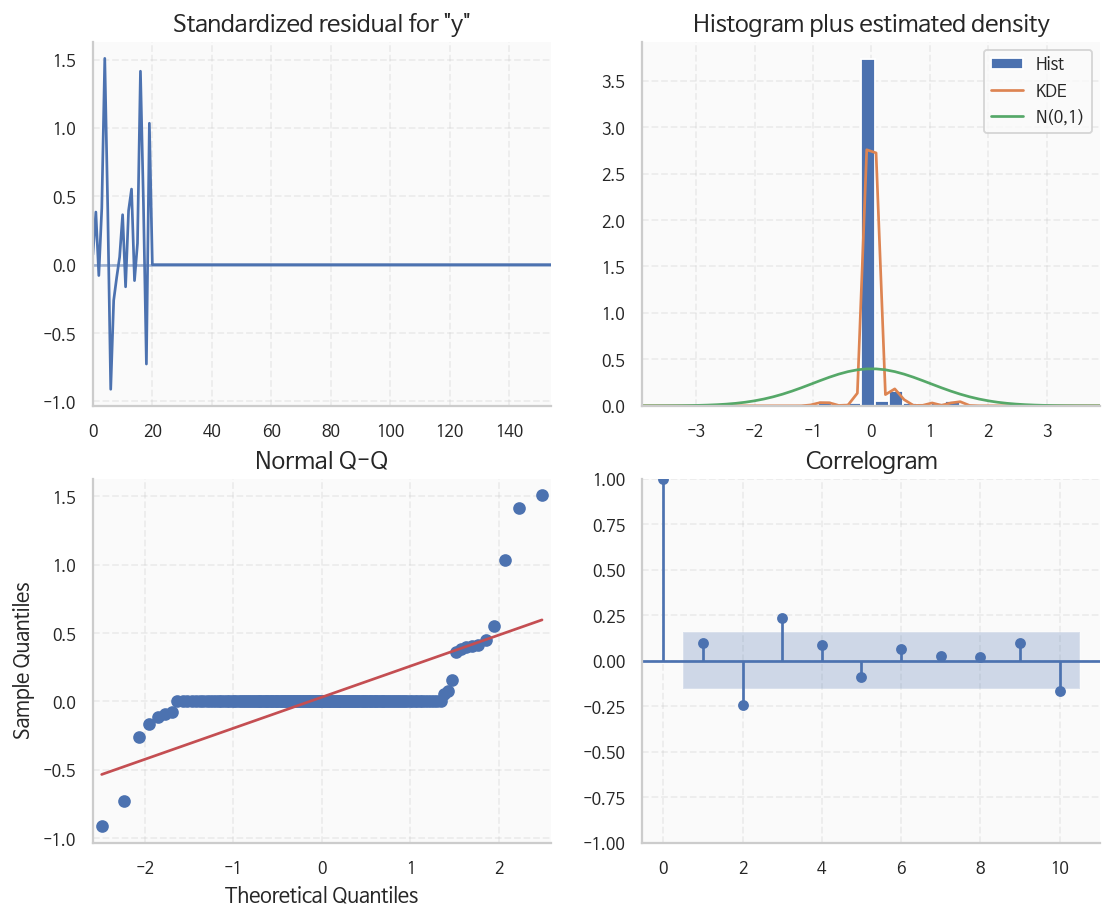

In [22]:
SARIMA_model_fit.plot_diagnostics(figsize=(10,8));

plt.show()

### 정량적 분석
- 귀무가설 : 잔차의 분포는 서로 상관관계가 없다
- 대립가설 : 잔차의 분포는 서로 상관관계가 있다.

In [23]:
residuals = SARIMA_model_fit.resid

acorr_ljungbox(residuals, np.arange(1, 11, 1))

,lb_stat,lb_pvalue
1,164.452306,1.204908e-37
2,323.492378,5.682279e-71
3,477.225004,4.112594e-103
4,625.873329,3.892024e-134
5,769.522046,4.531617e-164
6,908.070876,6.760477e-193
7,1041.751628,1.145125e-220
8,1170.426295,2.350599e-247
9,1294.139628,5.704098e-273
10,1412.979701,1.563260e-297


## 예측
- 12개월의 윈도우로 롤링 예측 수행하도록 정의

In [24]:
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    """
    일정 간격(window)마다 데이터를 갱신하며 미래를 예측하는 함수

    Args:
        df: 전체 시계열 데이터프레임
        train_len: 초기 학습 데이터의 길이
        horizon: 전체 예측 목표 기간 (테스트 데이터 길이)
        window: 한 번에 예측할 스텝(간격) 및 모델 갱신 주기
        method: 예측 방법 ('last_season', 'SARIMA')
    """
    total_len = train_len + horizon

    # --- 1. 계절성 나이브 모델 (Last Season) ---
    if method == 'last_season':
        pred_last_season = []
        for i in range(train_len, total_len, window):
            # 현재 시점(i) 직전의 window만큼의 데이터를 가져와서 그대로 예측값으로 사용
            # (계절성 패턴이 반복된다고 가정하는 단순 방식)
            last_season = df['y'][i-window:i].values
            pred_last_season.extend(last_season)
        return pred_last_season

    # --- 2. SARIMA 모델 (Seasonal ARIMA) ---
    elif method == 'SARIMA':
        pred_SARIMA = []
        for i in range(train_len, total_len, window):
            # 윈도우가 이동할 때마다 현재 시점(i)까지의 데이터를 사용하여 모델 재학습
            # order=(2,1,3): 비계절성 파라미터
            # seasonal_order=(1,1,3,12): 계절성 파라미터 (12개월 주기)
            model = SARIMAX(df['y'][:i],
                            order=(2, 1, 3),
                            seasonal_order=(1, 1, 3, 12),
                            simple_differencing=False)
            res = model.fit(disp=False)

            # 현재 시점(i)부터 다음 window 끝까지의 예측 수행
            predictions = res.get_prediction(0, i + window - 1)
            # 예측값 중 방금 계산한 미래 구간(Out-of-sample) 데이터만 추출
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_SARIMA.extend(oos_pred)

        return pred_SARIMA

In [25]:
pred_df = df[168:]
pred_df.head()

,ds,y
168,2005-07-01,15.829550
169,2005-08-01,17.554701
170,2005-09-01,18.100864
171,2005-10-01,17.496668
172,2005-11-01,19.347265


In [26]:
TRAIN_LEN = 168
HORIZON = 36
WINDOW = 12

pred_df['last_season'] = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, 'last_season')
pred_df.head()

,ds,y,last_season
168,2005-07-01,15.829550,15.339097
169,2005-08-01,17.554701,15.370764
170,2005-09-01,18.100864,16.142005
171,2005-10-01,17.496668,16.685754
172,2005-11-01,19.347265,17.636728


In [27]:
pred_df['SARIMA'] = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, 'SARIMA')
pred_df.head()

,ds,y,last_season,SARIMA
168,2005-07-01,15.829550,15.339097,16.751985
169,2005-08-01,17.554701,15.370764,16.687401
170,2005-09-01,18.100864,16.142005,17.188776
171,2005-10-01,17.496668,16.685754,18.089287
172,2005-11-01,19.347265,17.636728,18.662716


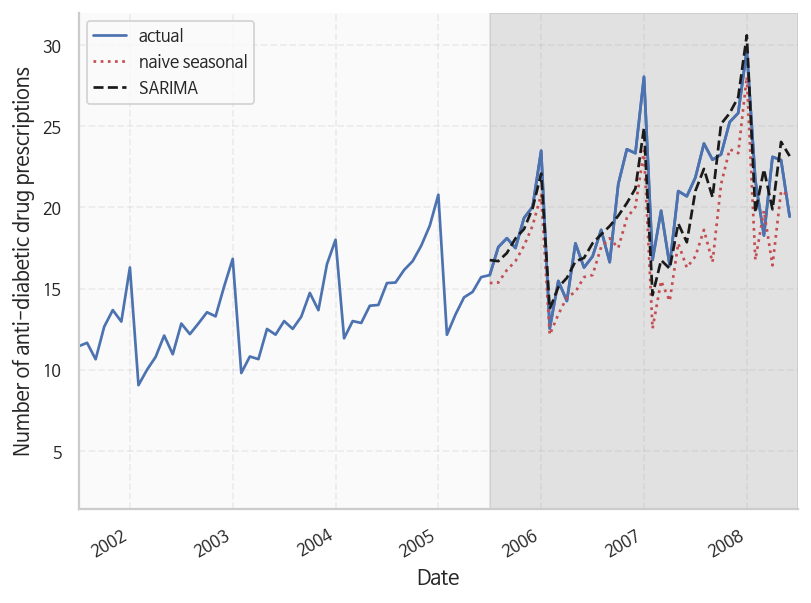

In [28]:
# 1. 그래프 도화지(Figure)와 축(Axis) 생성
fig, ax = plt.subplots()

# 2. 데이터 시각화
ax.plot(df.y)                                      # 전체 원본 데이터 흐름 출력
ax.plot(pred_df.y, 'b-', label='actual')           # 테스트 구간의 실제값 (파란색 실선)
ax.plot(pred_df.last_season, 'r:', label='naive seasonal') # 계절성 나이브 예측 (빨간색 점선)
ax.plot(pred_df.SARIMA, 'k--', label='SARIMA')     # SARIMA 모델 예측 (검은색 파선)

# 3. 축 레이블 설정
ax.set_xlabel('Date')
ax.set_ylabel('Number of anti-diabetic drug prescriptions')

# 4. 테스트 구간 강조 (하이라이트)
# ax.axvspan(시작, 끝): 인덱스 168부터 204까지 회색(#808080) 배경을 씌워 '예측 구간'임을 표시
ax.axvspan(168, 204, color='#808080', alpha=0.2)

# 5. 범례 설정
ax.legend(loc=2) # 왼쪽 상단(Upper Left)에 범례 배치

# 6. X축 눈금 및 범위 세부 조정
# plt.xticks: 12개월 주기로 눈금을 표시하고, 레이블을 연도(1992~2008)로 변환
plt.xticks(np.arange(6, 203, 12), np.arange(1992, 2009, 1))
# plt.xlim: 그래프가 너무 길어지지 않도록 인덱스 120부터 마지막까지만 확대해서 보여줌
plt.xlim(120, 204)

# 7. 레이아웃 최적화
fig.autofmt_xdate() # 날짜 레이블이 겹치지 않도록 자동으로 기울임 처리
plt.tight_layout()  # 여백을 최소화하여 깔끔하게 정렬

# 8. 그래프 출력
plt.show()

## 모델 평가
- 직관적인 해석: 오차가 실제값의 몇 퍼센트(%)인지를 나타냅니다.
- 예를 들어 MAPE가 5%라면 "내 모델의 예측이 평균적으로 실제값에서 5% 정도 벗어나 있다"라고 쉽게 이해할 수 있습니다.
- 절대값 사용 (np.abs): 예측이 실제보다 높든 낮든 상관없이 오차의 크기만을 측정하기 위해 절대값을 취합니다.

In [29]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [30]:
mape_naive_seasonal = mape(pred_df.y, pred_df.last_season)
mape_SARIMA = mape(pred_df.y, pred_df.SARIMA)

print(mape_naive_seasonal, mape_SARIMA)

12.686561923100614 7.891409818230001


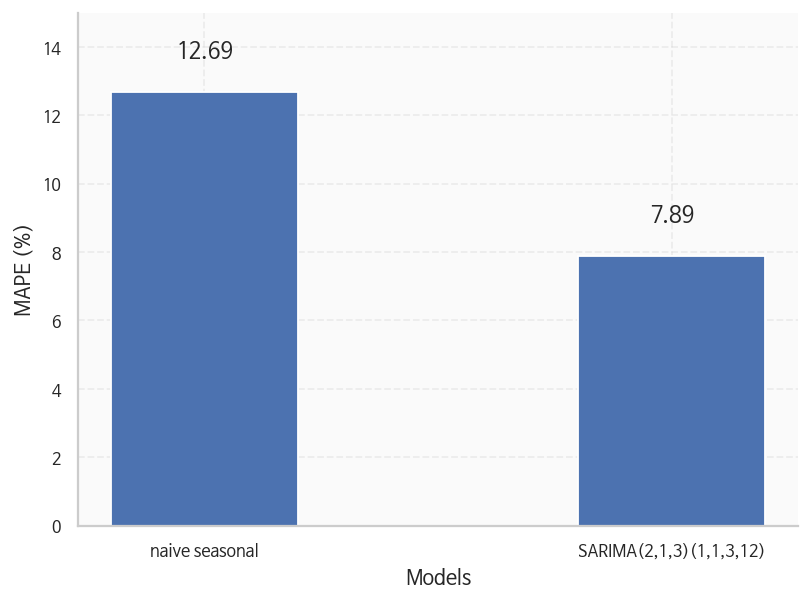

In [31]:
fig, ax = plt.subplots()

x = ['naive seasonal', 'SARIMA(2,1,3)(1,1,3,12)']
y = [mape_naive_seasonal, mape_SARIMA]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Models')
ax.set_ylabel('MAPE (%)')
ax.set_ylim(0, 15)

for index, value in enumerate(y):
    plt.text(x=index, y=value + 1, s=str(round(value,2)), ha='center')

plt.tight_layout()
plt.show()